# 01 - Market regimes (unsupervised)

**Question:** do the 1,000 bookings fall into distinct kinds of *moment*, or are they one undifferentiated smear?

This matters before any pricing rule exists. A surge multiplier needs the market to have recognisable states. If the moments don't separate, there is nothing to surge on and we should say so rather than build a rule on sand.

No target is used here. `historical_ride_cost` never enters this notebook's features - it was set by duration alone, so it cannot judge a market feature.

**Dependencies:** this notebook needs two packages the project doesn't have yet:

```
pip install pandas scikit-learn
```


In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# read_only so this never fights a `dbt build` holding the file
con = duckdb.connect("../dynamic_pricing/dynamic_pricing.duckdb", read_only=True)
rides = con.execute("select * from main.fct_rides").fetchdf()
con.close()

print(rides.shape)
rides.head()

Matplotlib is building the font cache; this may take a moment.


(1000, 14)


,ride_id,market_rider_count,market_driver_count,riders_per_driver,market_activity_volume,market_pressure_band,location_category,booking_time_of_day,vehicle_type,customer_loyalty_status,customer_past_ride_count,customer_avg_rating,expected_ride_duration_minutes,historical_ride_cost
0,db1a956571ac97eb47ca1a2a9dc1dc79,90,45,2.000000,135,Tight,Urban,Night,Premium,Silver,13,4.47,90,284.257273
1,3cc99f65c9b213268a46855550c8dc69,58,39,1.487179,97,Balanced,Suburban,Evening,Economy,Silver,72,4.06,43,173.874753
2,977b0c7f0bbd65547e9ff958dd7d9f23,42,31,1.354839,73,Balanced,Rural,Afternoon,Premium,Silver,0,3.99,76,329.795469
3,df79db8b056d647082fd3119f5da1920,89,28,3.178571,117,Tight,Rural,Afternoon,Premium,Regular,67,4.31,134,470.201232
4,d316656ed9048ec7aac967e10a5c2dc1,78,22,3.545455,100,Tight,Rural,Afternoon,Economy,Regular,74,3.77,149,579.681422


## Step 1 - what is a moment made of?

Only facets that describe the market at booking time. Four numeric columns:

| column | why |
|---|---|
| `market_rider_count` | raw demand |
| `market_driver_count` | raw supply |
| `riders_per_driver` | the pressure between them |
| `market_activity_volume` | how big the moment is |

**Categories are deliberately left out of the clustering.** k-means measures Euclidean distance, and Euclidean distance over one-hot dummies is not meaningful - the gap between Urban and Rural is not 1.41 of anything. Worse, one-hot columns would dominate the geometry by sheer count.

So: **cluster on the numbers, then profile the clusters with the categories.** That also gives a better answer to "what defines this moment" than a dummy coefficient would - we get to *describe* each regime in plain words.

In [2]:
FEATURES = [
    "market_rider_count",
    "market_driver_count",
    "riders_per_driver",
    "market_activity_volume",
]

X = rides[FEATURES]
X.describe().T

,count,mean,std,min,25%,50%,75%,max
market_rider_count,1000.0,60.372000,23.701506,20.00000,40.000000,60.000000,81.0,100.0
market_driver_count,1000.0,27.076000,19.068346,5.00000,11.000000,22.000000,38.0,89.0
riders_per_driver,1000.0,3.235461,2.533519,1.11236,1.658793,2.357143,3.8,17.6
market_activity_volume,1000.0,87.448000,38.627987,26.00000,55.000000,84.000000,116.0,188.0


## Step 2 - scaling lives here, not in dbt

`market_rider_count` runs 20-100. `riders_per_driver` runs ~1.1-17.6. Unscaled, k-means would cluster almost entirely on rider count, because it has the bigger numbers - not because it matters more.

So the features need standardising. **The reason it's done here and not in the intermediate model:** a z-score is *fitted*. Its mean and standard deviation are learned from whatever rows are present. Bake it into a table and every historical row's value silently changes the next time new data lands. Inside a `Pipeline`, the scaler is fitted once, carried with the model, and applied identically to anything scored later.

That's the general rule for the whole project:

> dbt holds transformations that are true regardless of who consumes them.
> The pipeline holds transformations that exist because a particular model demands them.

In [3]:
def make_pipeline(k):
    """Scaler + k-means as one fitted object. The scaler travels with the model."""
    return Pipeline([
        ("scale", StandardScaler()),
        ("cluster", KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
    ])

## Step 3 - how many regimes?

Two diagnostics, deliberately on **two separate panels** - they are different quantities on different scales and must never share an axis.

- **Inertia** (left): within-cluster spread. Always falls as k rises, so we look for the elbow, not the minimum.
- **Silhouette** (right): how well-separated the clusters are, -1 to 1. Roughly: above 0.5 is strong structure, 0.25-0.5 is weak but real, near 0 means the clusters are arbitrary slices of a continuum.

Silhouette is the one that answers our actual question.

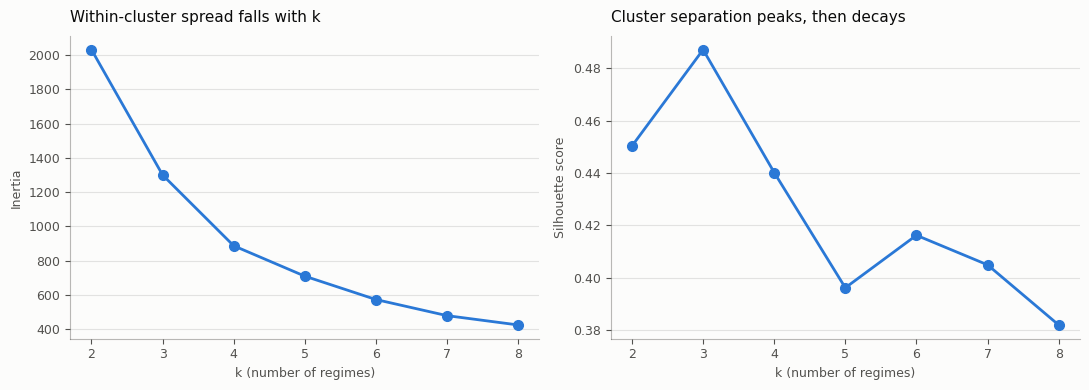

,k,inertia,silhouette
0,2,2030.739,0.450
1,3,1300.277,0.487
2,4,887.587,0.440
3,5,710.492,0.396
4,6,574.270,0.416
5,7,480.398,0.405
6,8,426.130,0.382


In [4]:
K_RANGE = range(2, 9)

inertia, silhouette = [], []
for k in K_RANGE:
    pipe = make_pipeline(k).fit(X)
    labels = pipe.named_steps["cluster"].labels_
    inertia.append(pipe.named_steps["cluster"].inertia_)
    silhouette.append(silhouette_score(pipe.named_steps["scale"].transform(X), labels))

INK, INK_2, ACCENT, SURFACE = "#0b0b0b", "#52514e", "#2a78d6", "#fcfcfb"

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor=SURFACE)
for ax, ys, title, ylab in [
    (axes[0], inertia, "Within-cluster spread falls with k", "Inertia"),
    (axes[1], silhouette, "Cluster separation peaks, then decays", "Silhouette score"),
]:
    ax.plot(list(K_RANGE), ys, color=ACCENT, linewidth=2, marker="o", markersize=7)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("k (number of regimes)", color=INK_2, fontsize=9)
    ax.set_ylabel(ylab, color=INK_2, fontsize=9)
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=INK_2, alpha=0.15, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(INK_2)
        ax.spines[side].set_alpha(0.4)
    ax.tick_params(colors=INK_2, labelsize=9)

plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(K_RANGE), "inertia": inertia, "silhouette": silhouette}).round(3)

## Step 4 - fit the chosen k

Set `K` from the silhouette peak above. Keep the scatter at 4 or fewer regimes: past that, colour alone stops being distinguishable and the plot needs facets instead.

In [5]:
K = 3   # <-- set from the silhouette panel above

pipe = make_pipeline(K).fit(X)
rides["regime"] = pipe.named_steps["cluster"].labels_
X_scaled = pipe.named_steps["scale"].transform(X)

final_silhouette = silhouette_score(X_scaled, rides["regime"])
print(f"k = {K}   silhouette = {final_silhouette:.3f}")

rides["regime"].value_counts().sort_index().rename("bookings").to_frame()

k = 3   silhouette = 0.487


,bookings
regime,
0,396
1,109
2,495


## Step 5 - what is each regime actually *like*?

This is the payoff. A cluster label is meaningless until it has a description a stakeholder could repeat.

First the numbers each regime was built from, then the categories it was *not* built from - the second is the real test. If regimes differ on time of day or location without ever having seen those columns, the structure is picking up something about the world.

In [6]:
profile = (
    rides.groupby("regime")[FEATURES + ["expected_ride_duration_minutes"]]
    .mean()
    .round(2)
)
profile["bookings"] = rides["regime"].value_counts().sort_index()
profile

,market_rider_count,market_driver_count,riders_per_driver,market_activity_volume,expected_ride_duration_minutes,bookings
regime,,,,,,
0,81.26,45.50,2.02,126.76,99.42,396
1,75.05,9.52,8.93,84.57,93.17,109
2,40.43,16.20,2.95,56.63,101.14,495


In [7]:
def composition(column):
    """Share of each regime made up by each level of `column`, in percent."""
    return (
        pd.crosstab(rides["regime"], rides[column], normalize="index")
        .mul(100).round(1)
    )

for col in ["booking_time_of_day", "location_category", "vehicle_type", "market_pressure_band"]:
    print(f"\n--- {col} (% of each regime) ---")
    print(composition(col))


--- booking_time_of_day (% of each regime) ---
booking_time_of_day  Afternoon  Evening  Morning  Night
regime                                                 
0                         23.2     24.7     23.7   28.3
1                         24.8     17.4     25.7   32.1
2                         25.9     23.0     25.1   26.1

--- location_category (% of each regime) ---
location_category  Rural  Suburban  Urban
regime                                   
0                   29.3      33.8   36.9
1                   37.6      32.1   30.3
2                   35.4      30.9   33.7

--- vehicle_type (% of each regime) ---
vehicle_type  Economy  Premium
regime                        
0                45.7     54.3
1                58.7     41.3
2                47.1     52.9

--- market_pressure_band (% of each regime) ---
market_pressure_band  Balanced  Scarce  Tight
regime                                       
0                         61.6     4.0   34.3
1                          0.0   

## Step 6 - the honest diagnostic

Three questions, in order of how badly a "yes" would hurt:

1. **Is this real structure, or did k-means just slice a continuum?** k-means always returns k clusters, even from uniform noise. Compare the silhouette against the same data with the labels shuffled - that's the score structureless data earns.
2. **Are the regimes anything more than `riders_per_driver` bands?** If the crosstab against `market_pressure_band` is near-diagonal, the clustering learned nothing the fixed thresholds in dbt didn't already encode - which would be a finding, not a failure. It would mean one number describes the moment and we can skip the model.
3. **Do they look separate?** PCA to two dimensions and look. PCA is for the eye only - the clustering happened in the full four-dimensional space.

In [8]:
shuffled = rides["regime"].sample(frac=1, random_state=RANDOM_STATE).to_numpy()
baseline = silhouette_score(X_scaled, shuffled)

print(f"silhouette, fitted labels   : {final_silhouette:.3f}")
print(f"silhouette, shuffled labels : {baseline:.3f}   <- what no structure looks like")

print("\n--- regime vs the fixed dbt bands (% of each regime) ---")
print(composition("market_pressure_band"))

silhouette, fitted labels   : 0.487
silhouette, shuffled labels : -0.022   <- what no structure looks like

--- regime vs the fixed dbt bands (% of each regime) ---


market_pressure_band  Balanced  Scarce  Tight
regime                                       
0                         61.6     4.0   34.3
1                          0.0   100.0    0.0
2                         25.9    23.4   50.7


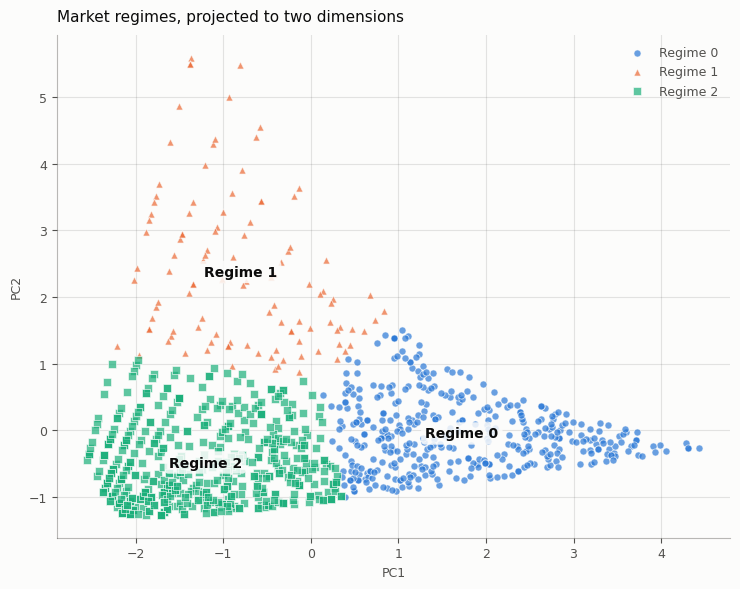

In [9]:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

# Fixed order, validated for all-pairs separation. Markers and centroid labels
# carry identity too, so the plot never depends on colour alone.
REGIME_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
REGIME_MARKERS = ["o", "^", "s", "D"]

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for r in sorted(rides["regime"].unique()):
    m = rides["regime"] == r
    ax.scatter(
        coords[m, 0], coords[m, 1],
        s=26, alpha=0.7,
        color=REGIME_COLORS[r % len(REGIME_COLORS)],
        marker=REGIME_MARKERS[r % len(REGIME_MARKERS)],
        linewidths=0.6, edgecolors=SURFACE,
        label=f"Regime {r}",
    )
    # direct label at the centroid - identity without reading the legend
    ax.annotate(
        f"Regime {r}",
        (coords[m, 0].mean(), coords[m, 1].mean()),
        color=INK, fontsize=10, fontweight="bold",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc=SURFACE, ec="none", alpha=0.85),
    )

ax.set_title("Market regimes, projected to two dimensions", color=INK, fontsize=11, loc="left", pad=10)
ax.set_xlabel("PC1", color=INK_2, fontsize=9)
ax.set_ylabel("PC2", color=INK_2, fontsize=9)
ax.grid(color=INK_2, alpha=0.15, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(INK_2)
    ax.spines[side].set_alpha(0.4)
ax.tick_params(colors=INK_2, labelsize=9)
ax.legend(frameon=False, labelcolor=INK_2, fontsize=9, loc="best")

plt.tight_layout()
plt.show()

## What to conclude

Write the answer down before moving on - it decides whether Stage 5 has a foundation.

- **Silhouette well above the shuffled baseline, regimes differ on categories they never saw** -> the moment is real and describable. Name each regime and carry the names forward.
- **Silhouette barely above baseline** -> the market is a continuum, not a set of states. A surge *curve* on `riders_per_driver` is then the honest instrument, not a set of regime tiers.
- **Regimes map almost one-to-one onto `market_pressure_band`** -> one number already describes the moment. Keep the fixed thresholds, drop the clustering, and say in the memo that you tested for hidden structure and found none beyond the ratio.

All three are publishable results. Only the third feels like a failure, and it isn't.